## Assignment 02 

Binary classification using Deep Neural Networks Example: Classify movie reviews into positive" reviews and "negative" reviews, just based on the text content of the reviews. Use IMDB dataset

In [14]:
import pandas as pd

In [15]:
df = pd.read_csv("imdb_data.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [16]:
# Use Label Encoder in the sentiment field
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['sentiment'] = encoder.fit_transform(df['sentiment'])
df['sentiment']

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [17]:
X = df['review']
y = df['sentiment']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Machine learning models, especially Deep Learning models like Neural Networks, cannot read or process raw text. They are giant math equations, which means they only accept numbers.

To feed a movie review into a neural network, you have to translate English into mathematics. This process is called Tokenization and Sequencing.

Building a Dictionary (Tokenization): The computer reads through all the reviews in your training data and creates a dictionary of every unique word it sees. It sorts these words by how often they appear. The most common word (usually "the") gets the ID 1, the second most common ("a") gets 2, the word "movie" might get 34, and so on.

Translation (Sequencing): The computer goes back through your reviews and replaces every word with its corresponding integer ID. A review like "The movie was good" becomes a sequence of numbers like [1, 34, 15, 87].

Handling Unknowns (OOV): When you eventually test your model on real-world data, it will inevitably encounter words it has never seen before. Instead of crashing or ignoring the word entirely, we use an Out Of Vocabulary (OOV) token. We tell the dictionary, "If you see a word you don't know, assign it a specific ID (like 2) so the model knows a word is there, even if it doesn't know what it is."

In [18]:
VOCAB_SIZE = 10000
MAX_LEN = 200

VOCAB_SIZE: You are telling the model to only remember the top 10,000 most frequently used words. Language has hundreds of thousands of words, but rare words (like specific character names or typos) don't help the model learn general sentiment and just eat up memory.

MAX_LEN: Reviews come in all sizes, but neural networks require fixed-size inputs. You are defining a variable here stating that all reviews will eventually be forced to be exactly 200 words long (you will likely use this variable in your next block of code for a process called "padding").

In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words = VOCAB_SIZE, oov_token='<OOV>')

In [20]:
tokenizer.fit_on_texts(X_train) # Notice it only fits on X_train, not X_test. You only want the model to build its dictionary based on the data it studies. The test data must remain completely unseen.
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad the training sequences so that all sequences are of equal length
# - maxlen: maximum length of sequences after padding/truncating
# - padding="post": pads zeros at the end of each sequence
# - truncating="post": truncates extra words from the end if a sequence is too long
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

We have converted words into numbers (e.g., "good" = 14, "terrible" = 89). However, simple integers are a problem for math equations. The number 89 is much larger than 14, but that doesn't mean "terrible" is mathematically "greater" than "good."

To fix this, neural networks use Word Embeddings.

Spatial Meaning (Embeddings): Instead of a single integer, an Embedding layer translates each word into a coordinate in a multi-dimensional space. Words with similar meanings (like "good" and "great") end up physically close to each other in this space, while opposites (like "good" and "terrible") are pushed far apart.

Finding Patterns (Hidden Layers): Once the words are mapped in space, the network passes them through "hidden layers" of neurons. These neurons look for complex combinations. For example, one neuron might learn to activate when it sees the word "not" immediately followed by "good."

The Final Verdict (Output Layer): Finally, all these complex patterns are funneled down into a single neuron that acts as a judge, outputting a final probability score of whether the whole review was positive or negative.

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

# Create a sequential model — layers added one after another
model = Sequential()

# Embedding layer:
# - input_dim: size of the vocabulary (total unique words, e.g., 10,000)
# - output_dim: size of the dense embedding vector for each word (e.g., 64-dimensional)
# - input_length: length of input sequences (after padding)
# This layer turns each integer (word index) into a learnable dense vector
model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN))

# Flatten layer:
# - Converts the 2D output from the Embedding layer (MAX_LEN x 64) into a 1D vector
# - This is needed before passing it to Dense layers
model.add(Flatten())

# First dense (fully connected) hidden layer:
# - 64 neurons
# - ReLU activation helps the network learn non-linear patterns
model.add(Dense(64, activation='relu'))

# Output layer:
# - 1 neuron since this is binary classification (positive vs negative review)
# - Sigmoid activation outputs a probability between 0 and 1
model.add(Dense(1, activation='sigmoid'))

# Compile the model:
# - 'adam' is an efficient optimizer for training
# - 'binary_crossentropy' is the appropriate loss function for binary classification
# - 'accuracy' tracks how many predictions are correct
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display a summary of the model architecture
model.summary()

c:\Users\LENOVO\Desktop\BE-Lab-Assignments\LP-V\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,# train the model y_train,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7885 - loss: 0.4271 - val_accuracy: 0.8474 - val_loss: 0.3429
Epoch 2/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9553 - loss: 0.1225 - val_accuracy: 0.8400 - val_loss: 0.4600
Epoch 3/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9945 - loss: 0.0179 - val_accuracy: 0.8449 - val_loss: 0.6847
Epoch 4/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9996 - loss: 0.0025 - val_accuracy: 0.8360 - val_loss: 0.8385
Epoch 5/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9999 - loss: 7.0089e-04 - val_accuracy: 0.8451 - val_loss: 0.8697
Epoch 6/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 5.8775e-05 - val_accuracy: 0.8429 - val_loss: 0.8995
Epoch 7/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 3.0529e-05 - val_accuracy: 0.8466 - val_loss: 0.9267
Epoch 8/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 1.0000 - loss: 1.6419e-05 

In [25]:
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=1)
print('Test Accuracy: ', accuracy)
print('Test Loss: ', loss)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8425 - loss: 1.0116
Test Accuracy:  0.8425333499908447
Test Loss:  1.011592984199524


In [26]:
# get predicted probabilities and convert to binary labels
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


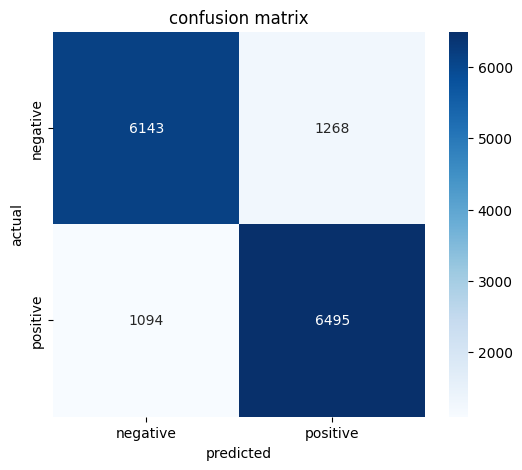

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()

In [28]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.83      0.84      7411
    positive       0.84      0.86      0.85      7589

    accuracy                           0.84     15000
   macro avg       0.84      0.84      0.84     15000
weighted avg       0.84      0.84      0.84     15000

